In [ ]:
# arviz 라이브러리를 사용하기 위해 az로 가져옵니다.
import arviz as az
# matplotlib의 pyplot을 plt로 불러와서 시각화를 진행합니다.
import matplotlib.pyplot as plt
# numpy를 np로 가져와서 수치 계산 및 배열 작업을 수행합니다.
import numpy as np
# scipy.special 모듈에서 binom 함수와 beta 함수를 불러옵니다.
from scipy.special import binom, beta
# preliz 라이브러리를 pz로 가져와서 확률 분포 관련 기능을 사용합니다.
import preliz as pz


In [ ]:
pz.Beta(1, 1).plot_interactive()

In [ ]:
pz.Beta(1, 1).plot_interactive(figsize=(12, 4), kind="cdf")

In [ ]:
pz.Beta(1, 1).rvs()

In [ ]:
beta = pz.Beta(1, 1).rvs(1000)
mean = beta.mean()
plt.figure(figsize=(12, 4))
plt.hist(beta, bins=30, density=True, alpha=0.5)
plt.axvline(mean, color="red", linestyle="--", label=f"평균 = {mean:.2f}")
plt.title("Beta(1, 1) 확률 변수")
plt.xlabel("값")
plt.ylabel("밀도")
plt.legend()

In [ ]:
pz.Beta(1, 1).plot_pdf(figsize=(12, 4))
plt.title("Beta(1, 1) 확률 밀도 함수")

In [ ]:
pz.Binomial(30, 0.5).plot_interactive()

In [ ]:
binom = pz.Binomial(30, 0.5).rvs(1000)
mean = binom.mean()
plt.figure(figsize=(12, 4))
plt.hist(binom, bins=30, alpha=0.5)
plt.axvline(mean, color="red", linestyle="--", label=f"평균 = {mean:.2f}")
plt.title("Binomial(30, 0.5) 확률 변수")
plt.xlabel("값")
plt.ylabel("밀도")
plt.legend()
plt.show()

In [ ]:
plt.hist(pz.BetaBinomial(alpha=2, beta=5, n=5).rvs(1000), 
         bins=[0, 1, 2, 3, 4, 5, 6], 
         density=True, align="left")
pz.BetaBinomial(alpha=2, beta=5, n=5).plot_pdf();

In [ ]:
dist = pz.Normal(0, 1)
a = -6
b = 6
num = 1000
x_s = np.linspace(a, b, num)
base = (b - a) / num
np.sum(dist.pdf(x_s) * base)  # 면적 계산

In [ ]:
plt.figure(figsize=(12, 9))

n_trials = [0, 1, 2, 3, 4, 8, 16, 32, 50, 150]
n_heads = [0, 1, 1, 1, 1, 4, 6, 9, 13, 48]
theta_real = 0.35

beta_params = [(1, 1), (20, 20), (1, 4)]
x = np.linspace(0, 1, 2000)

for idx, N in enumerate(n_trials):
    if idx == 0:
        plt.subplot(4, 3, 2)
        plt.xlabel('θ')
    else:
        plt.subplot(4, 3, idx+3)
        plt.xticks([])
    y = n_heads[idx]
    for (α_prior, β_prior) in beta_params:
        posterior = pz.Beta(α_prior + y, β_prior + N - y).pdf(x)
        plt.plot(x, posterior, lw=4)

    plt.plot(theta_real, 0, ms=9, marker='o', mec='w', mfc='k')
    plt.plot(0, 0, label=f'{N:4d} trials\n{y:4d} heads', alpha=0)
    plt.xlim(0, 1)
    plt.ylim(0, 12)
    plt.legend()
    plt.yticks([])

In [ ]:
dist = pz.Beta()
pz.maxent(dist, 0.1, 0.7, 0.9)

In [ ]:
pz.StudentT(5).plot_interactive()

In [1]:
%matplotlib inline
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import preliz as pz
import pandas as pd

az.style.use('arviz-white')

In [2]:
def P(S, A, prob_dist):
    if set(A).issubset(set(S)):
        return sum([prob_dist[event] for event in A])
    else:
        return 0
    
S = {"s", "b", "c"}
A = {"s"}
B = {"s", "b"}
prob_dist = {"s": 0.5, "b": 0.25, "c": 0.25}

In [3]:
P(S, A, prob_dist)

0.5

In [4]:
P(S, B, prob_dist)

0.75

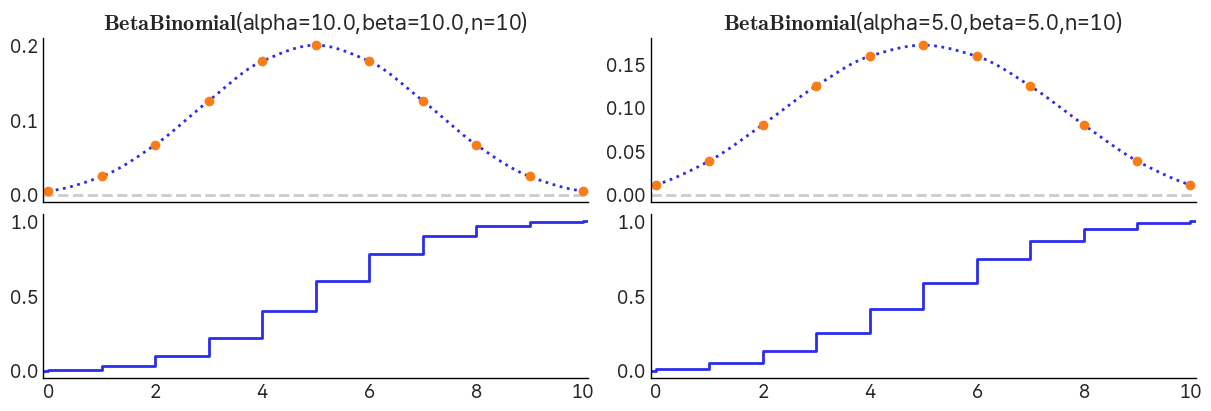

In [5]:
_, ax = plt.subplots(2, 2, figsize=(12, 4), sharex=True)
alpha = [10, 5]
beta = [10, 5]
for idx, (alpha, beta) in enumerate(zip(alpha, beta)):
    pz.BetaBinomial(alpha, beta, 10).plot_pdf(legend="title", ax=ax[0, idx]);
    pz.BetaBinomial(alpha, beta, 10).plot_cdf(legend=None, ax=ax[1, idx]);

In [2]:
pz.Normal(0, 1).plot_interactive(xy_lim=(None, None, 0, 1.5))

interactive(children=(FloatSlider(value=0.0, description='mu (-inf, inf)', max=10.0, min=-10.0, style=SliderSt…

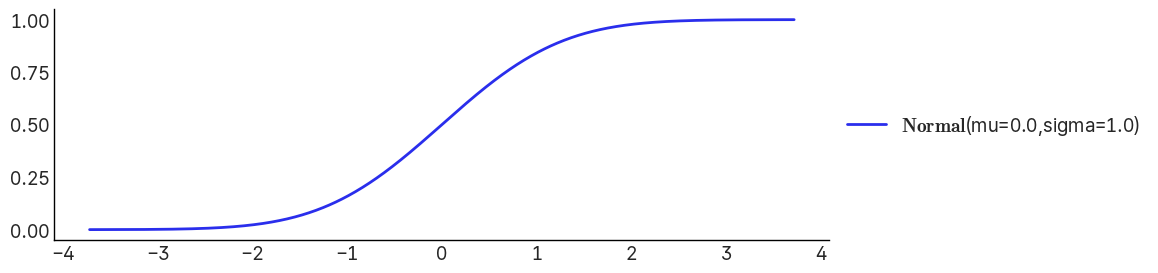

In [3]:
pz.Normal(0, 1).plot_cdf(figsize=(10, 3));

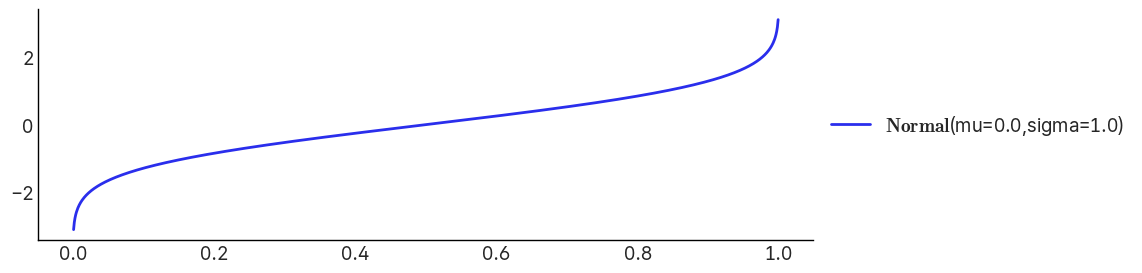

In [4]:
pz.Normal(0, 1).plot_ppf(figsize=(10, 3));

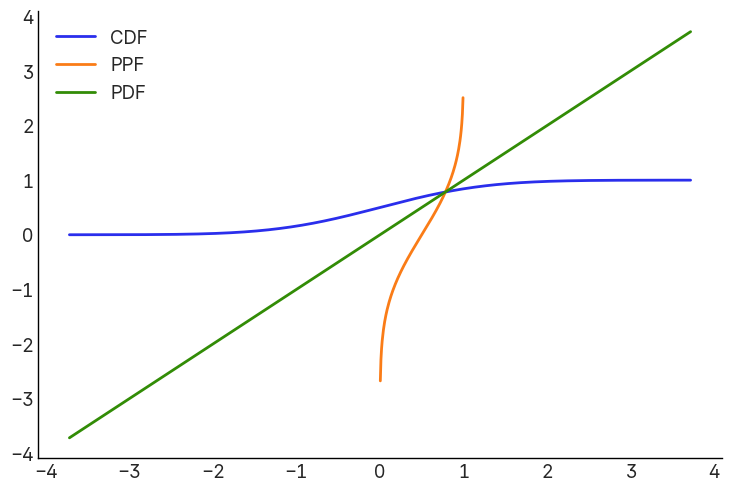

In [14]:
dist = pz.Normal(0, 1)
x_values = dist.xvals("full")[::]

cdf_v = dist.cdf(x_values)
ppf_v = dist.ppf(x_values)
pdf_v = dist.ppf(cdf_v)
plt.plot(x_values, cdf_v, label="CDF")
plt.plot(x_values, ppf_v, label="PPF")
plt.plot(x_values, pdf_v, label="PDF")
plt.legend()

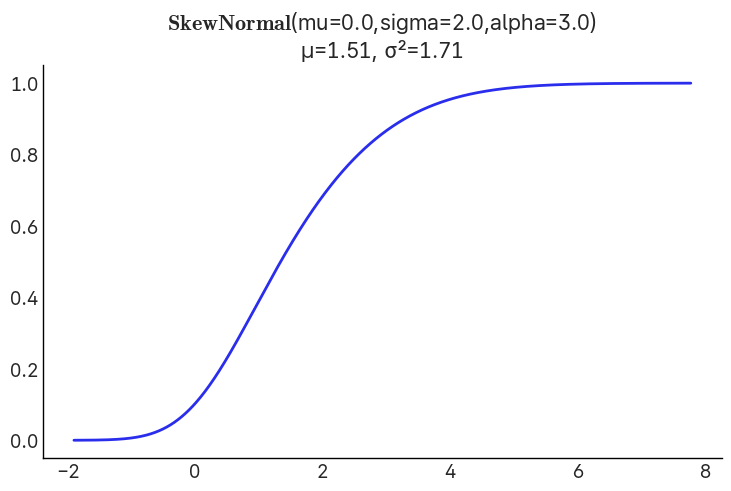

In [16]:
skn = pz.SkewNormal(0, 2, 3)
skn.plot_cdf(moments=["m", "v"], legend="title");

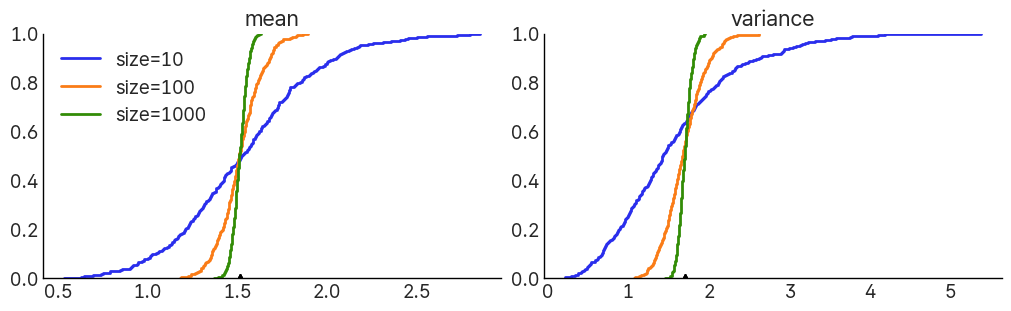

In [18]:
sizes = [10, 100, 1000]
_, ax = plt.subplots(1, 2, figsize=(10, 3))

true_mean, true_var = skn.rv_frozen.stats("mv")
for idx, size in enumerate(sizes):
    rnd = skn.rvs((size, 500))
    ax[0].ecdf(rnd.mean(0), color=f"C{idx}", label=f"{size=}")
    ax[1].ecdf(rnd.var(0), color=f"C{idx}", )
    ax[0].plot(true_mean, 0, "k^")
    ax[1].plot(true_var, 0, "k^")
    ax[0].set_title("mean")
    ax[1].set_title("variance")
    ax[0].legend()

<Axes: >

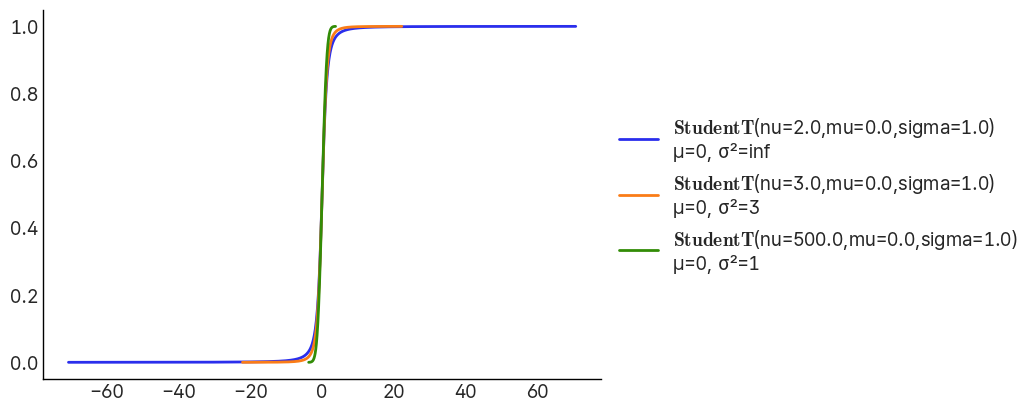

In [22]:
t_2 = pz.StudentT(2, 0, 1)
t_3 = pz.StudentT(3, 0, 1)
t_500 = pz.StudentT(500, 0, 1)

t_2.plot_cdf(moments=["m", "v"], legend="legend")
t_3.plot_cdf(moments=["m", "v"], legend="legend")
t_500.plot_cdf(moments=["m", "v"], legend="legend")


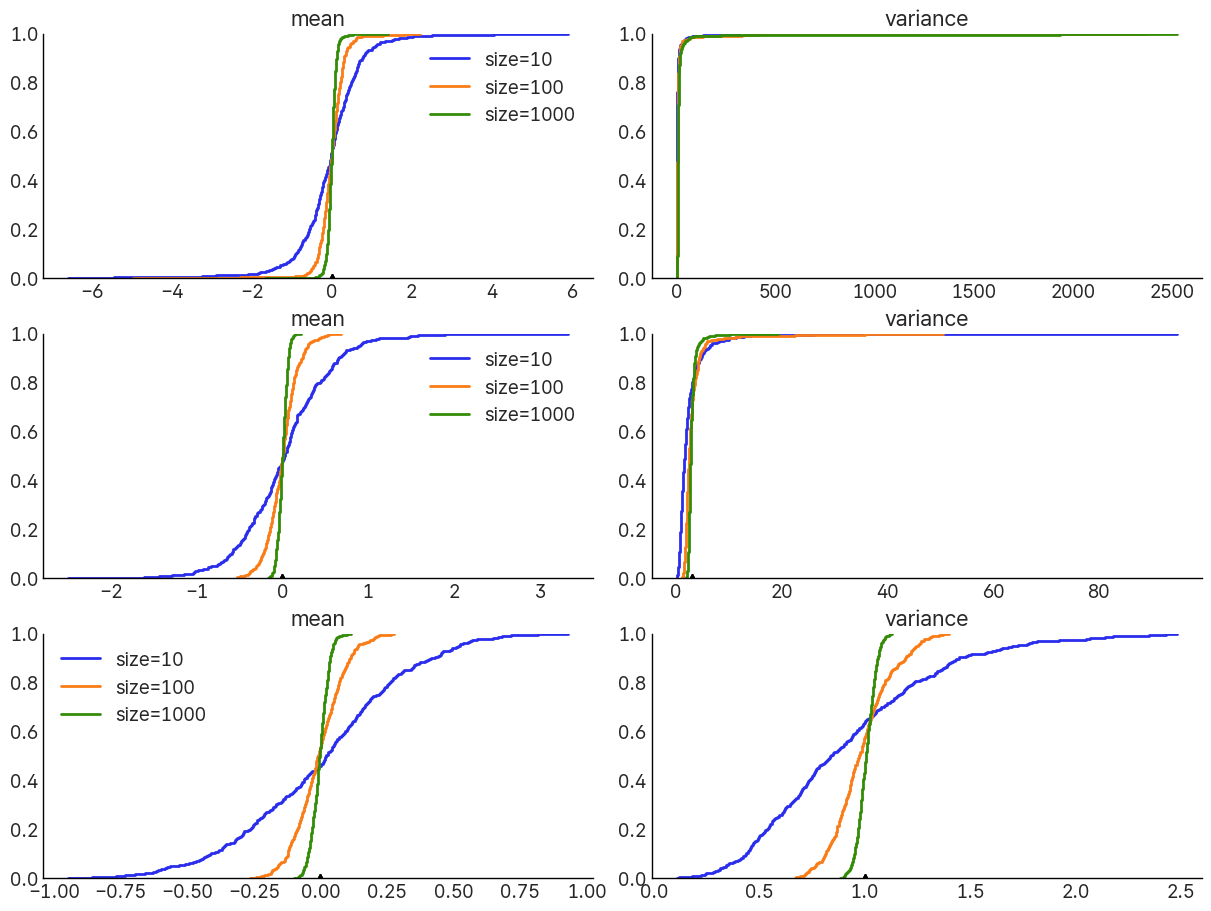

In [32]:
sizes = [10, 100, 1000]
_, ax = plt.subplots(3, 2, figsize=(12, 9))

for idx, dist in enumerate([t_2, t_3, t_500]):
    true_mean, true_var = dist.rv_frozen.stats("mv")
    for jdx, size in enumerate(sizes):
        rnd = dist.rvs((size, 500))
        ax[idx, 0].ecdf(rnd.mean(0), color=f"C{jdx}", label=f"{size=}")
        ax[idx, 1].ecdf(rnd.var(0), color=f"C{jdx}", )
        ax[idx, 0].plot(true_mean, 0, "k^")
        ax[idx, 1].plot(true_var, 0, "k^")
        ax[idx, 0].set_title("mean")
        ax[idx, 1].set_title("variance")
        ax[idx, 0].legend()

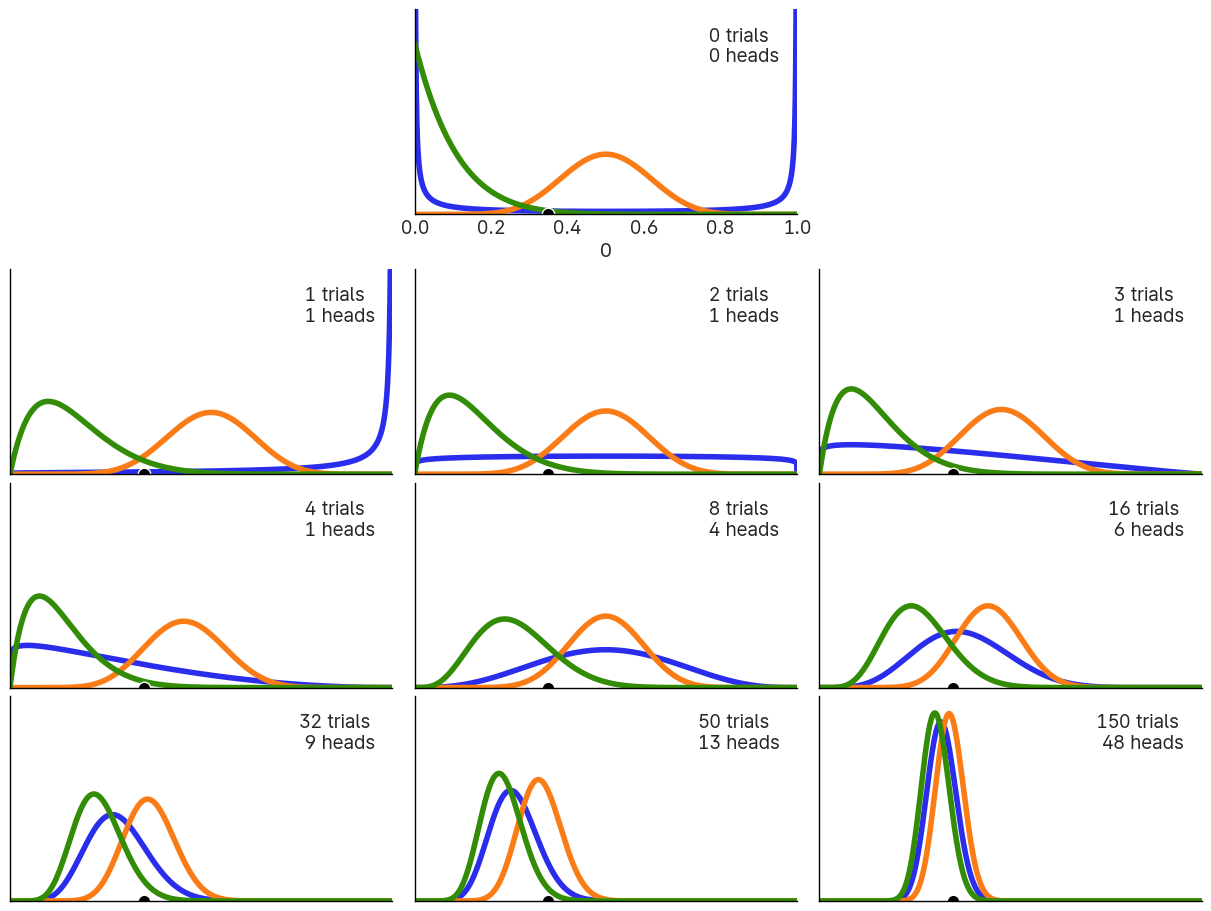

In [35]:
plt.figure(figsize=(12, 9))

n_trials = [0, 1, 2, 3, 4, 8, 16, 32, 50, 150]
n_heads = [0, 1, 1, 1, 1, 4, 6, 9, 13, 48]
theta_real = 0.35

beta_params = [(0.1, 0.1), (10, 10), (1, 10)]
x = np.linspace(0, 1, 2000)

for idx, N in enumerate(n_trials):
    if idx == 0:
        plt.subplot(4, 3, 2)
        plt.xlabel('0')
    else:
        plt.subplot(4, 3, idx + 3)
        plt.xticks([])
    y = n_heads[idx]
    for (a_prior, b_prior) in beta_params:
        posterior = pz.Beta(a_prior + y, b_prior + N - y).pdf(x)
        plt.plot(x, posterior, lw=4)

    plt.plot(theta_real, 0, ms=9, marker='o', mec='w', mfc='k' )
    plt.plot(0,0, label=f'{N:4d} trials\n{y:4d} heads', alpha=0)
    plt.xlim(0, 1)
    plt.ylim(0, 12)
    plt.legend()
    plt.yticks([])


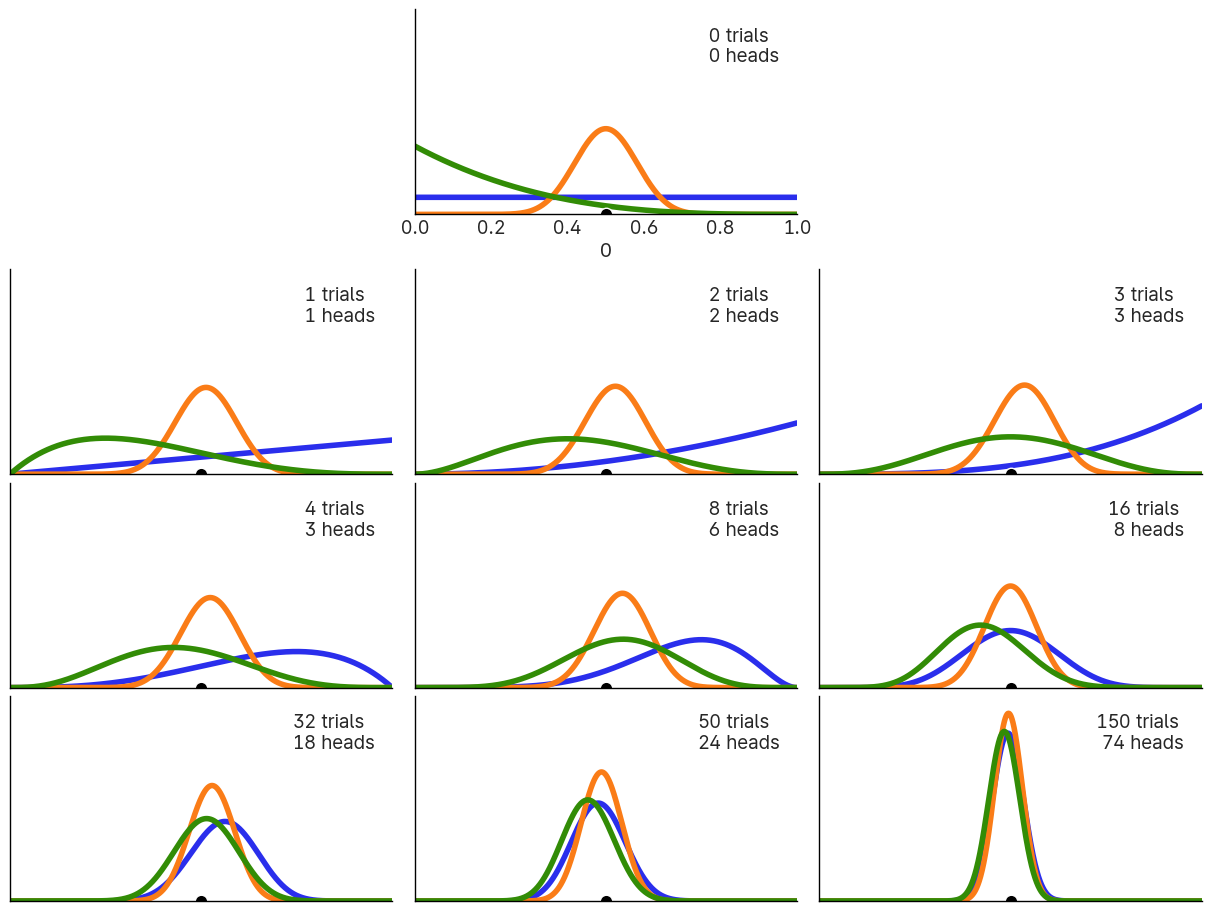

In [37]:
plt.figure(figsize=(12, 9))

n_trials = [0, 1, 2, 3, 4, 8, 16, 32, 50, 150]
n_heads = [ 0, 1 ,2, 3, 3, 6, 8, 18, 24, 74]
theta_real = 0.5

beta_params = [(1, 1), (20, 20), (1, 4)]
x = np.linspace(0, 1, 2000)

for idx, N in enumerate(n_trials):
    if idx == 0:
        plt.subplot(4, 3, 2)
        plt.xlabel('0')
    else:
        plt.subplot(4, 3, idx+3)
        plt.xticks([])
    y = n_heads[idx]
    for (a_proir, b_prior) in beta_params:
        posterior = pz.Beta(a_proir + y, b_prior + N - y).pdf(x)
        plt.plot(x, posterior, lw=4)
    
    plt.plot(theta_real, 0, ms=9, marker='o', mec='w', mfc='k')
    plt.plot(0, 0, label=f'{N:4d} trials\n{y:4d} heads', alpha=0)
    plt.xlim(0, 1)
    plt.ylim(0, 12)
    plt.legend()
    plt.yticks([])

In [38]:
import pandas as pd
from IPython.display import display, HTML

# 데이터 생성
data = {
    "total_bill": [29.03, 27.18, 22.67, 17.82, 18.78],
    "tip": [5.92, 2.00, 2.00, 1.75, 3.00],
    "sex": ["Male", "Female", "Male", "Male", "Female"],
    "smoker": ["No", "Yes", "Yes", "No", "No"],
    "day": ["Sat", "Sat", "Sat", "Sat", "Thur"],
    "time": ["Dinner", "Dinner", "Dinner", "Dinner", "Dinner"],
    "size": [3, 2, 2, 2, 2]
}
index = [239, 240, 241, 242, 243]
df = pd.DataFrame(data, index=index)

# CSS 스타일 정의
style = """
<style scoped>
    table.dataframe {
        font-size: 11px;
        border-collapse: collapse;
        margin-bottom: 5px;
    }
    .dataframe th, .dataframe td {
        padding: 4px 6px;
        text-align: center;
        border: 1px solid black;
    }
    .dataframe thead th {
        text-align: center;
    }
    .table-caption {
        font-family: Arial, sans-serif;
        font-size: 14px;
        font-weight: bold;
        margin-top: 6px;
    }
</style>
"""

# HTML 조합
html = style + df.to_html(classes='dataframe') + """
<div class='table-caption'><b>Table 2.5:</b> Sample data from a restaurant</div>
"""

# 결과 출력
display(HTML(html))

,total_bill,tip,sex,smoker,day,time,size
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2
243,18.78,3.00,Female,No,Thur,Dinner,2
